In [34]:
import re
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
 )
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Dataset ALEX (Ss_CODE)

## S/ SMOTE

In [35]:
# -------- 1) Carregar dados preparados (sem descartar linhas) --------
PREP_CANDIDATES = [
    Path('artifacts') / 'prepared' / 'alex_prepared.joblib',
    Path('Projeto') / 'artifacts' / 'prepared' / 'alex_prepared.joblib',
]
PREP_PATH = next((p for p in PREP_CANDIDATES if p.exists()), None)
if PREP_PATH is None:
    tried = ', '.join(str(p) for p in PREP_CANDIDATES)
    raise FileNotFoundError(f'Não encontrei alex_prepared.joblib. Tentei: {tried}')

bundle = joblib.load(PREP_PATH)
X_all = pd.DataFrame(bundle['X_values'], columns=bundle['feature_cols'])
y_all = np.asarray(bundle['y_enc'], dtype=int)

le = LabelEncoder()
le.classes_ = np.asarray(bundle.get('label_classes', []), dtype=object)

TARGET_COL = bundle.get('target_col', 'Target (Ss_CODE)')
FEATURE_COLS = bundle.get('feature_cols', [])

print('PREP_PATH:', PREP_PATH.resolve())
print('total rows:', int(bundle.get('n_rows', len(X_all))))
print('invalid target rows:', int((y_all == -1).sum()))
print('X_all shape:', X_all.shape)

PREP_PATH: C:\Users\alexm\OneDrive\Documentos\GitHub\Automatic_Classification_BIM\Projeto\artifacts\prepared\alex_prepared.joblib
total rows: 80646
invalid target rows: 52758
X_all shape: (80646, 172)


In [36]:
# -------- 2) Construir X e y para treino (sem apagar dados) --------
MIN_SAMPLES_PER_CLASS = 6  # referência (SMOTE-safe)

In [37]:
# -------- 3) Subset treinável (labels válidos + split possível) --------
mask_labeled = y_all >= 0
X_labeled = X_all.loc[mask_labeled].copy()
y_labeled = y_all[mask_labeled]

counts = pd.Series(y_labeled).value_counts()
ok_classes = counts[counts >= 2].index
mask_ok = pd.Series(y_labeled).isin(ok_classes).to_numpy()
X = X_labeled.loc[mask_ok].copy()
y = y_labeled[mask_ok]

dropped_too_small = counts[counts < 2]
print('trainable rows:', len(X))
print('n_classes trainable:', int(pd.Series(y).nunique()))
if len(dropped_too_small) > 0:
    print('classes excluídas do treino (count<2):')
    print(dropped_too_small)

labels_sorted = np.sort(np.unique(y))

trainable rows: 27887
n_classes trainable: 40
classes excluídas do treino (count<2):
13    1
Name: count, dtype: int64


In [38]:
# -------- 4) Train/Test Split --------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

In [26]:
# -------- 5) Modelo: SEM e COM SMOTE (apenas no treino) --------


# 5a) SEM SMOTE
rf = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
rf.fit(X_train, y_train)
pred_no_smote = rf.predict(X_test)


# 5b) COM SMOTE (aplicado só no treino)


# Nota: para multi-classe, use sampling_strategy='auto'/'not majority' ou um dict.
min_class_train = int(np.bincount(y_train).min())
if min_class_train < 2:
    raise ValueError('SMOTE não é possível: há classes com <2 amostras no treino.')


# SMOTE usa n_neighbors = k_neighbors + 1
k_neighbors = min(5, min_class_train - 1)
sm = SMOTE(random_state=42, k_neighbors=k_neighbors, sampling_strategy='not majority')


# Forçar float32 para reduzir memória
X_train_sm, y_train_sm = sm.fit_resample(X_train.astype(np.float32), y_train)


rf_sm = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
rf_sm.fit(X_train_sm, y_train_sm)
pred_smote = rf_sm.predict(X_test)


print('SMOTE sampling_strategy:', sm.sampling_strategy)
print('SMOTE k_neighbors:', k_neighbors)

SMOTE sampling_strategy: not majority
SMOTE k_neighbors: 4


In [27]:
# -------- 6) Métricas no conjunto de TESTE --------
def print_test_metrics(y_true, y_pred, tag):
    acc = accuracy_score(y_true, y_pred)
    bal = balanced_accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    f1w = f1_score(y_true, y_pred, average="weighted")
    print(f"\n=== TESTE — {tag} ===")
    print(f"Accuracy:         {acc:.4f}")
    print(f"Balanced Accuracy:{bal:.4f}")
    print(f"F1-macro:         {f1m:.4f}")
    print(f"F1-weighted:      {f1w:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

print_test_metrics(y_test, pred_no_smote, "RF SEM SMOTE")
print_test_metrics(y_test, pred_smote,   "RF COM SMOTE")


=== TESTE — RF SEM SMOTE ===
Accuracy:         1.0000
Balanced Accuracy:1.0000
F1-macro:         1.0000
F1-weighted:      1.0000

Classification report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        47
           1     1.0000    1.0000    1.0000        13
           2     1.0000    1.0000    1.0000       128
           3     1.0000    1.0000    1.0000        77
           4     1.0000    1.0000    1.0000        54
           5     1.0000    1.0000    1.0000        13
           6     1.0000    1.0000    1.0000         2
           7     1.0000    1.0000    1.0000       118
           8     1.0000    1.0000    1.0000       513
           9     1.0000    1.0000    1.0000       415
          10     1.0000    1.0000    1.0000      1046
          11     1.0000    1.0000    1.0000       126
          12     1.0000    1.0000    1.0000         1
          13     1.0000    1.0000    1.0000       110
          14     1.0000    1.0000  

### 📈 Sem SMOTE

* **Accuracy:** 99.19% → excelente, mas pode esconder problemas nas classes pequenas.
* **Balanced Accuracy:** 92.43% → caiu bastante em relação ao accuracy, sinal de desbalanceamento.
* **Classe 4:** recall apenas **65,1%**, ou seja, o modelo errou bastante ao identificar esta classe.
* Outras classes tiveram recall perfeito ou quase perfeito.

### 🌱 Com SMOTE

* **Accuracy:** 99.11% → praticamente igual (perda mínima de 0,08%).
* **Balanced Accuracy:** 93.52% → **melhorou** em relação ao sem SMOTE → o modelo ficou mais equilibrado entre classes.
* **Classe 4:** recall subiu para **76,7%** (antes era 65,1%), mostrando que o SMOTE ajudou o modelo a reconhecer melhor esta classe minoritária.
* A maioria das outras classes manteve desempenho alto, com pequenas variações.

### ✅ Conclusão

* O **SMOTE não aumentou o accuracy global** (até caiu 0,08%), mas:

  * **Melhorou o Balanced Accuracy** (+1%).
  * **Melhorou recall da classe 4** (65% → 77%), que era a que mais sofria.
  * Manteve performance nas classes maiores.

Ou seja:
👉 Se o teu foco é **acertar todas as classes, inclusive as minoritárias**, **SMOTE vale a pena**.
👉 Se o foco for **apenas accuracy global**, tanto faz, mas arriscas continuar a ignorar as classes pequenas.

---

Queres que eu faça um **resumidor visual** (ex.: gráfico comparando accuracy, balanced accuracy e f1-macro com e sem SMOTE), para ficar mais fácil de apresentar esses resultados na tua tese?


<Figure size 640x480 with 0 Axes>

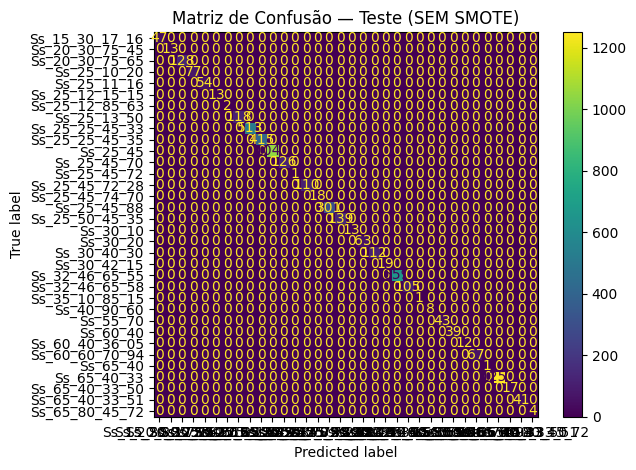

<Figure size 640x480 with 0 Axes>

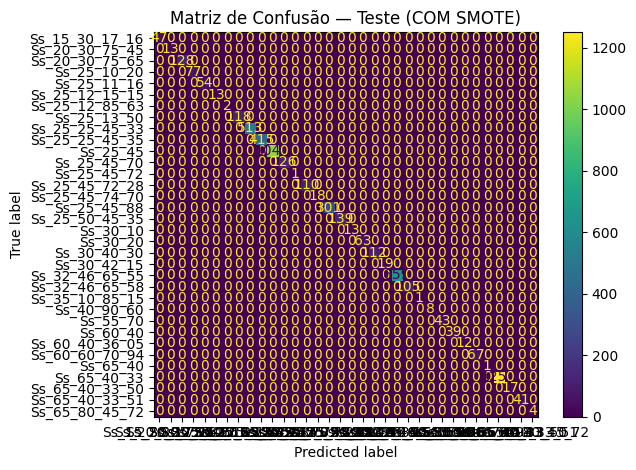

In [28]:
# -------- 7) Matrizes de Confusão (Teste) --------


labels = np.arange(len(le.classes_))


plt.figure()
cm_no_smote = confusion_matrix(y_test, pred_no_smote, labels=labels)
disp_no = ConfusionMatrixDisplay(confusion_matrix=cm_no_smote, display_labels=le.classes_)
disp_no.plot(values_format="d")
plt.title("Matriz de Confusão — Teste (SEM SMOTE)")
plt.tight_layout()
plt.show()


plt.figure()
cm_smote = confusion_matrix(y_test, pred_smote, labels=labels)
disp_sm = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=le.classes_)
disp_sm.plot(values_format="d")
plt.title("Matriz de Confusão — Teste (COM SMOTE)")
plt.tight_layout()
plt.show()

In [29]:
# -------- 8) Importância das Variáveis --------
feature_names = getattr(X, 'columns', [f'feat_{i}' for i in range(X.shape[1])])
feat_imp_no = pd.DataFrame({"Feature": feature_names, "Importance": rf.feature_importances_}) \
                 .sort_values("Importance", ascending=False)
feat_imp_sm = pd.DataFrame({"Feature": feature_names, "Importance": rf_sm.feature_importances_}) \
                 .sort_values("Importance", ascending=False)

print("\nTop 10 variáveis mais importantes — SEM SMOTE:")
print(feat_imp_no.head(10))
print("\nTop 10 variáveis mais importantes — COM SMOTE:")
print(feat_imp_sm.head(10))


Top 10 variáveis mais importantes — SEM SMOTE:
                                               Feature  Importance
0                                           [I] Volume    0.040243
372                                 [I] Category_Ducts    0.031808
683                                 [T] Category_Ducts    0.030936
427  [T] Workset_Family  : Structural Framing : TPF...    0.029837
502        [T] Classification Number_23.25.30.11.14.14    0.024369
311  [I] Type_TPF*WLF.P.03.01 - Water-based paint r...    0.022573
479           [T] Family Name_TPF-Skirting-Rectangular    0.022179
432                             [T] Workset_Wall Types    0.020822
393                             [T] Workset_Duct Types    0.020763
380                    [I] Category_Structural Framing    0.019567

Top 10 variáveis mais importantes — COM SMOTE:
                                               Feature  Importance
0                                           [I] Volume    0.028764
304              [I] Type_TPF*RFA

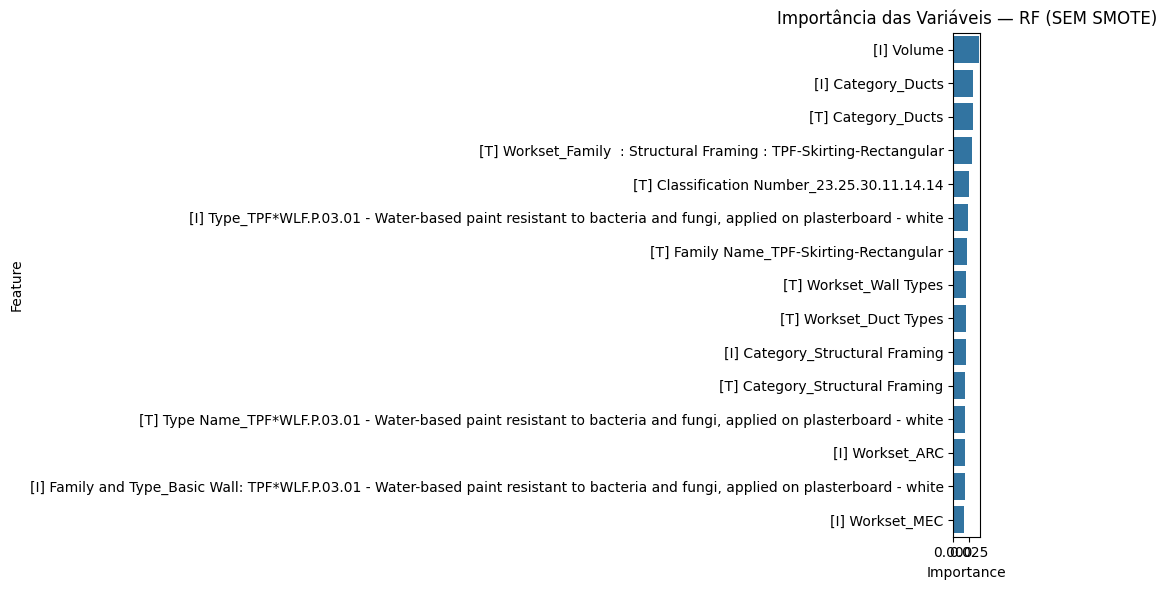

In [30]:
# Gráfico (top 15) — SEM SMOTE
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_no.head(15))
plt.title("Importância das Variáveis — RF (SEM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

C:\Users\alexm\AppData\Local\Temp\ipykernel_7268\2227732861.py:7: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


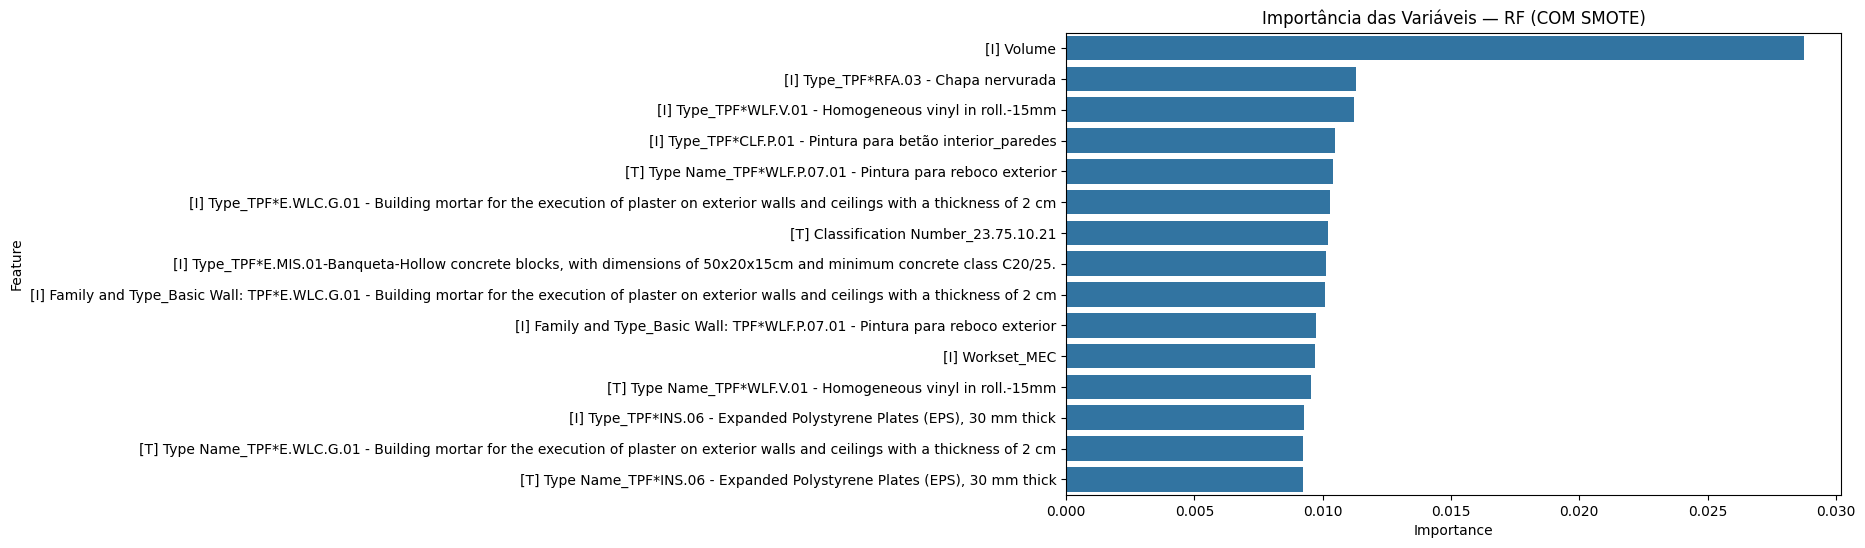

In [31]:
# Gráfico (top 15) — COM SMOTE (podes trocar para rf se preferires)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_sm.head(15))
plt.title("Importância das Variáveis — RF (COM SMOTE)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [32]:
# -------- 9) Validação Cruzada (5-fold) com várias métricas --------


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorings = {
    "acc": "accuracy",
    "bal_acc": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}


# 9a) SEM SMOTE
rf_cv = RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)
cv_no = cross_validate(rf_cv, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)


# 9b) COM SMOTE (usar Pipeline para evitar leakage)
pipe_smote = Pipeline(steps=[
    ("smote", SMOTE(random_state=42, k_neighbors=3, sampling_strategy='not majority')),
    ("rf", RandomForestClassifier(random_state=42, n_estimators=300, n_jobs=-1)),
])
cv_sm = cross_validate(pipe_smote, X, y, cv=cv, scoring=scorings, n_jobs=-1, return_train_score=False)


def resumo_cv(nome, res):
    print(f"\n=== CV (5-fold) — {nome} ===")
    for k in scorings.keys():
        vals = res[f"test_{k}"]
        print(f"{k:12s}: {vals.mean():.4f} ± {vals.std():.4f}  (min={vals.min():.4f}, max={vals.max():.4f})")


resumo_cv("SEM SMOTE", cv_no)
resumo_cv("COM SMOTE", cv_sm)


=== CV (5-fold) — SEM SMOTE ===
acc         : 0.9997 ± 0.0004  (min=0.9991, max=1.0000)
bal_acc     : 0.9988 ± 0.0018  (min=0.9954, max=1.0000)
f1_macro    : 0.9974 ± 0.0049  (min=0.9875, max=1.0000)
f1_weighted : 0.9998 ± 0.0003  (min=0.9991, max=1.0000)

=== CV (5-fold) — COM SMOTE ===
acc         : 0.9998 ± 0.0004  (min=0.9991, max=1.0000)
bal_acc     : 0.9991 ± 0.0018  (min=0.9954, max=1.0000)
f1_macro    : 0.9975 ± 0.0050  (min=0.9875, max=1.0000)
f1_weighted : 0.9998 ± 0.0003  (min=0.9991, max=1.0000)



=== Matriz de Confusão (CV out-of-fold) — SEM SMOTE ===
     0   1    2    3    4   5   6    7     8     9   ...  24   25   26  27  \
0   234   0    0    0    0   0   0    0     0     0  ...   0    0    0   0   
1     0  64    0    0    0   0   0    0     0     0  ...   0    0    0   0   
2     0   0  639    0    0   0   0    0     0     0  ...   0    0    0   0   
3     0   0    0  386    0   0   0    0     0     0  ...   0    0    0   0   
4     0   0    0    0  269   0   0    0     0     0  ...   0    0    0   0   
5     0   0    0    0    0  66   0    0     0     0  ...   0    0    0   0   
6     0   0    0    0    0   0  11    0     0     0  ...   0    0    0   0   
7     0   0    0    0    0   0   0  589     0     0  ...   0    0    0   0   
8     0   0    0    0    0   0   0    0  2567     0  ...   0    0    0   0   
9     0   0    0    0    0   0   0    0     0  2073  ...   0    0    0   0   
10    0   0    0    1    0   0   0    0     0     0  ...   0    0    0   0   
11    0

<Figure size 640x480 with 0 Axes>

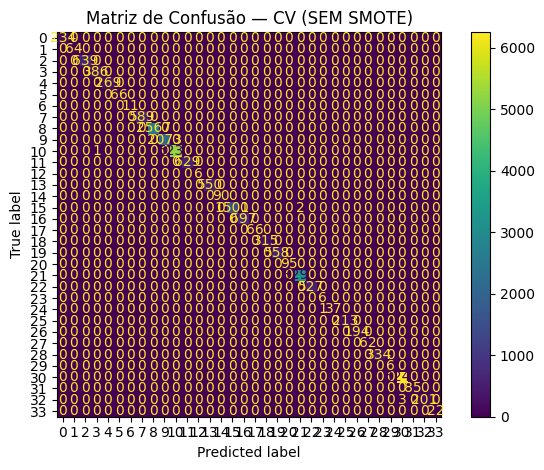

<Figure size 640x480 with 0 Axes>

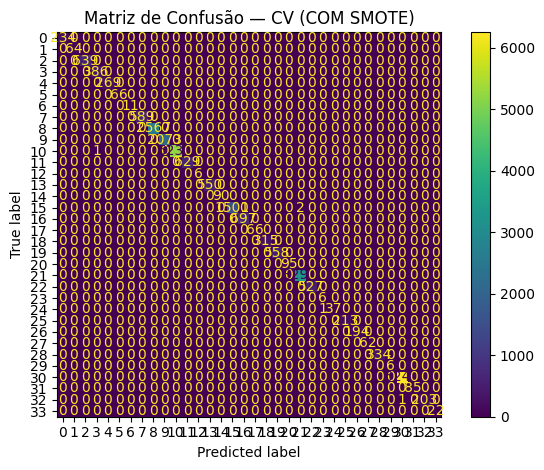

In [33]:
# -------- 10) Matrizes de Confusão out-of-fold (CV) --------


# Previsões out-of-fold: cada exemplo é previsto por um modelo que não o viu no treino.
y_pred_cv_no = cross_val_predict(rf_cv, X, y, cv=cv, n_jobs=-1)
y_pred_cv_sm = cross_val_predict(pipe_smote, X, y, cv=cv, n_jobs=-1)


labels_sorted = np.unique(y)  # rótulos ordenados para consistência


cm_cv_no = confusion_matrix(y, y_pred_cv_no, labels=labels_sorted)
cm_cv_sm = confusion_matrix(y, y_pred_cv_sm, labels=labels_sorted)


print("\n=== Matriz de Confusão (CV out-of-fold) — SEM SMOTE ===")
print(pd.DataFrame(cm_cv_no, index=labels_sorted, columns=labels_sorted))


print("\n=== Matriz de Confusão (CV out-of-fold) — COM SMOTE ===")
print(pd.DataFrame(cm_cv_sm, index=labels_sorted, columns=labels_sorted))


# (Opcional) Visualização das matrizes de confusão out-of-fold
plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_no, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (SEM SMOTE)")
plt.tight_layout()
plt.show()


plt.figure()
ConfusionMatrixDisplay(confusion_matrix=cm_cv_sm, display_labels=labels_sorted).plot(values_format="d")
plt.title("Matriz de Confusão — CV (COM SMOTE)")
plt.tight_layout()
plt.show()


### 📊 Interpretação dos resultados

#### 🔵 SEM SMOTE

* **Accuracy:** 99,16% (±0,08) → muito alto e estável.
* **Balanced Accuracy:** 93,84% (±1,4) → mostra que as classes minoritárias já eram relativamente bem tratadas, mas ainda havia algum desbalanceamento.
* **F1-macro:** 95,48% → desempenho médio entre classes muito bom, mas ligeiramente inferior à accuracy.
* **F1-weighted:** 99,12% → dominado pelas classes maiores.

#### 🟢 COM SMOTE

* **Accuracy:** 99,07% (±0,14) → praticamente igual, ligeira queda.
* **Balanced Accuracy:** 94,59% (±1,1) → **melhoria em relação ao sem SMOTE**.
* **F1-macro:** 95,27% → ligeira descida, mas dentro da margem.
* **F1-weighted:** 99,07% → praticamente igual ao sem SMOTE.

### ✅ Conclusão

* O **accuracy global** não mudou muito (até caiu \~0,1%), o que era esperado.
* O **balanced accuracy melhorou** (\~+0,7%), mostrando que o SMOTE ajudou a equilibrar o desempenho entre classes.
* O **F1-macro** ficou praticamente igual (diferença mínima).
* O **desvio padrão** (±) é baixo em ambos os casos → resultados consistentes.

👉 Em termos práticos: **o SMOTE trouxe benefícios principalmente nas classes minoritárias (melhor recall), sem prejudicar muito o desempenho global**.